In [2]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import pickle
import os
from sklearn.neural_network import MLPRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from project_utils import MC_forward, loader_drained, rmse

## Synthetic Data

In [6]:
np.random.seed(123)
n_samples   = 10000

sigma3_options = [50., 100., 200., 300., 400.]
eps_max_options = [0.2, 0.22, 0.24, 0.26, 0.28, 0.3]

X_syn = []
Y_syn = []

for _ in range(n_samples):
    K      = np.random.uniform(5000.,  100000.)
    G      = np.random.uniform(2000.,   50000.)
    phi    = np.random.uniform(20.,     42.)
    psi    = np.random.uniform(0.,      min(15., phi - 1.))
    sigma3 = np.random.choice(sigma3_options)
    eps_max = np.random.choice(eps_max_options)

    params_syn = np.array([K, G, phi, psi])

    try:
        q, epsqd, epsv, p = MC_forward(params_syn, c=0, sigma3=sigma3, eps_max=eps_max, n_steps=1000, load_tag=110, obs_eps1=None)
        
        q_max      = q.max()
        p_at_qmax  = p[np.argmax(q)]
        eta_max    = q_max / (p_at_qmax + 1e-8)
        epsv_max   = epsv.max()
        epsv_at_qmax = epsv[np.argmax(q)]
        YoungsE = (q[5] - q[0]) / (epsqd[5] - epsqd[0] + 1e-10) # early slope - Young's modulus
        pnorm_range = (p.max() - p.min())/ (sigma3 + 1e-10)

        features = np.array([
            q_max    / sigma3,      # normalised peak strength
            eta_max,                # peak stress ratio
            YoungsE  / sigma3,      # normalised stiffness
            epsv_max  * 100,        # peak volumetric strain (%)
            epsv_at_qmax * 100,     # strain at peak q (%)
            sigma3,                 # confining stress (kPa)
            pnorm_range             # normalised p range
        ])

        X_syn.append(features)
        Y_syn.append(params_syn)
    except:
        pass

X_syn = np.array(X_syn) # features
Y_syn = np.array(Y_syn) # parameters

print(f"Generated {len(X_syn)} samples")

Generated 10000 samples


In [7]:
# Save synthetic data so that we don't have to regenerate it (~10 mins) every time we restart notebook kernels
np.save('X_syn.npy', X_syn)
np.save('Y_syn.npy', Y_syn)
print("Synthetic data saved")

Synthetic data saved


## Training

In [8]:
# Load synthetic data
X_syn = np.load('X_syn.npy')
Y_syn = np.load('Y_syn.npy')
print(f"Loaded {len(X_syn)} samples")

Loaded 10000 samples


In [9]:
x_train, x_test, y_train, y_test = train_test_split(X_syn, Y_syn, test_size=0.2, random_state=1222) #randomly samples X/Y_syn

# normalize
scaler_X = StandardScaler()
scaler_Y = StandardScaler()

X_train_s = scaler_X.fit_transform(x_train)
X_test_s  = scaler_X.transform(x_test)
Y_train_s = scaler_Y.fit_transform(y_train)

In [ ]:
num_models = 10 #number of models to build for the ensemble
min_nhn = 16 #minimum number of hidden neurons to loop through (nhn = 'number hidden neurons')
max_nhn = 64 #maximum number of hidden neurons to loop through
max_hidden_layers = 2 #maximum number of hidden layers to loop through (nhl = 'number hidden layers')
batch_size = 32
solver = 'adam'     # use stochastic gradient descent as an optimization method (weight updating algorithm)
activation = 'tanh'
learning_rate_init = 0.001
max_iter = 2000     # max number of epochs to run
early_stopping = True #True = stop early if validation error begins to rise
validation_fraction = 0.2 #fraction of training data to use as validation


y_out_ensemble = []
RMSE_ensemble  = []
nhn_best       = []
nhl_best       = []
all_models     = []

for model_num in range(num_models):
    
    print('Model Number: ' + str(model_num))
    
    RMSE = []
    nhn = []
    nhl = []
    models = []
    
    for num_hidden_layers in range(1,max_hidden_layers+1):
    
        print('\t # Hidden Layers = ' + str(num_hidden_layers))
    
        for num_hidden_neurons in range(min_nhn,max_nhn+1): #for each number of hidden neurons

            print('\t\t # hidden neurons = ' + str(num_hidden_neurons))
            
            hidden_layer_sizes = tuple([num_hidden_neurons] * num_hidden_layers)
            model = MLPRegressor(hidden_layer_sizes=hidden_layer_sizes, 
                                 verbose=False,
                                 max_iter=max_iter, 
                                 early_stopping = early_stopping,
                                 validation_fraction = validation_fraction,
                                 batch_size = batch_size,
                                 solver = solver,
                                 activation = activation,
                                 learning_rate_init = learning_rate_init)

            model.fit(X_train_s,Y_train_s) # train with normalzied data

            Y_pred_s = model.predict(X_test_s)
            Y_pred   = scaler_Y.inverse_transform(Y_pred_s)

            RMSE.append(rmse(y_test[:, 2], Y_pred[:, 2]))
            
            nhn.append(num_hidden_neurons)
            nhl.append(num_hidden_layers)
            
            models.append(model) ### NEW
        
    indBest = RMSE.index(np.min(RMSE)) #index of model with lowest RMSE
    RMSE_ensemble.append(np.min(RMSE))
    nhn_best.append(nhn[indBest])
    nhl_best.append(nhl[indBest])
    all_models.append(models[indBest]) ### NEW
    #nhn_best.append(indBest+1) #the number of hidden neurons that achieved best model performance of this model iteration
    y_out_ensemble.append(scaler_Y.inverse_transform(models[indBest].predict(X_test_s)))
    
    print('\t BEST: ' + str(nhl_best[model_num]) + ' hidden layers, '+ str(nhn_best[model_num]) + ' hidden neurons')

# Testing    
Y_ensemble_mean = np.mean(y_out_ensemble, axis=0)
param_names = ['K (kPa)', 'G (kPa)', 'φ (°)', 'ψ (°)']
for j, name in enumerate(param_names):
    print(f"  {name}: RMSE = {rmse(y_test[:, j], Y_ensemble_mean[:, j]):.3f}")

Model Number: 0
	 # Hidden Layers = 1
		 # hidden neurons = 16
		 # hidden neurons = 17
		 # hidden neurons = 18
		 # hidden neurons = 19
		 # hidden neurons = 20
		 # hidden neurons = 21
		 # hidden neurons = 22
		 # hidden neurons = 23
		 # hidden neurons = 24
		 # hidden neurons = 25
		 # hidden neurons = 26
		 # hidden neurons = 27
		 # hidden neurons = 28
		 # hidden neurons = 29
		 # hidden neurons = 30
		 # hidden neurons = 31
		 # hidden neurons = 32
		 # hidden neurons = 33
		 # hidden neurons = 34
		 # hidden neurons = 35
		 # hidden neurons = 36
		 # hidden neurons = 37
		 # hidden neurons = 38
		 # hidden neurons = 39
		 # hidden neurons = 40
		 # hidden neurons = 41
		 # hidden neurons = 42
		 # hidden neurons = 43
		 # hidden neurons = 44
		 # hidden neurons = 45
		 # hidden neurons = 46
		 # hidden neurons = 47
		 # hidden neurons = 48
		 # hidden neurons = 49
		 # hidden neurons = 50
		 # hidden neurons = 51
		 # hidden neurons = 52
		 # hidden neurons = 53
		 # hidden 

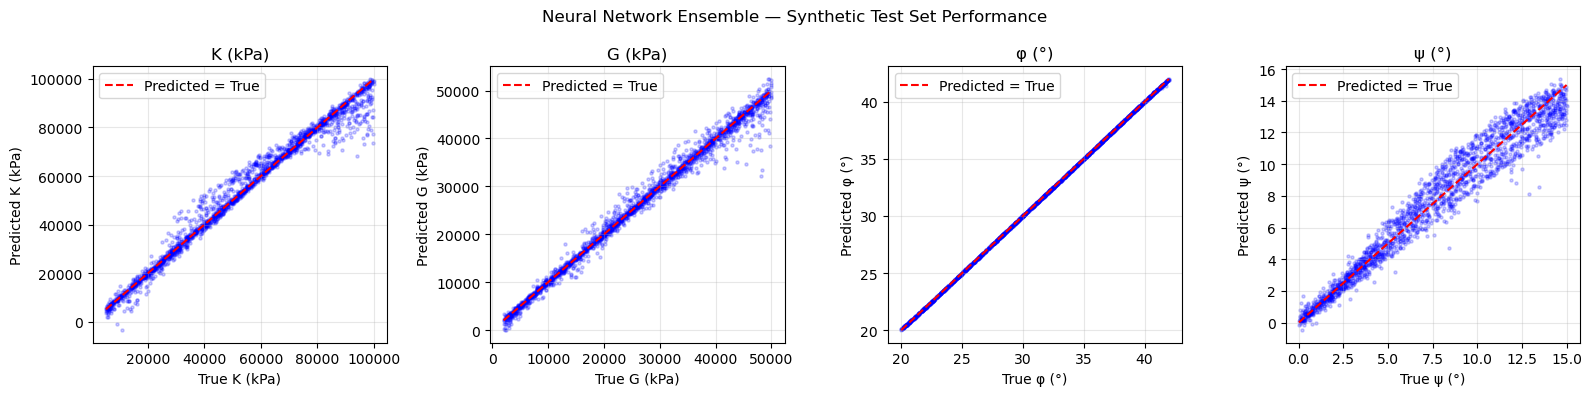

In [16]:
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
param_names = ['K (kPa)', 'G (kPa)', 'φ (°)', 'ψ (°)']

for j, name in enumerate(param_names):
    axes[j].scatter(y_test[:, j], Y_ensemble_mean[:, j], alpha=0.2, s=5, c='b')
    lims = [y_test[:, j].min(), y_test[:, j].max()]
    axes[j].plot(lims, lims, 'r--', lw=1.5, label='Predicted = True')
    axes[j].set_xlabel(f'True {name}')
    axes[j].set_ylabel(f'Predicted {name}')
    axes[j].set_title(name)
    axes[j].legend()
    axes[j].grid(alpha=0.3)

plt.suptitle('Neural Network Ensemble — Synthetic Test Set Performance', fontsize=12)
plt.tight_layout()
plt.savefig('outputs_MC/NN_test_performance.png', dpi=150, bbox_inches='tight')
plt.show()

In [12]:
# saves the trained models (takes ~45 minutes to run above)
pickle.dump(all_models, open('MC_ensemble.p', 'wb'))
pickle.dump(scaler_X,   open('MC_scaler_X.p', 'wb'))
pickle.dump(scaler_Y,   open('MC_scaler_Y.p', 'wb'))
print("Models and scalers saved")

Models and scalers saved


In [13]:
all_models = pickle.load(open('MC_ensemble.p', 'rb'))
scaler_X   = pickle.load(open('MC_scaler_X.p', 'rb'))
scaler_Y   = pickle.load(open('MC_scaler_Y.p', 'rb'))

In [18]:
data_dir = os.path.join('Karlsruhe-fine-sand-database-complete',
                        'TMD - triaxial-monotonic-drained')

X_obs     = []
test_names = []

In [19]:
for n in range(1, 26):
    test     = f'TMD{n}'
    filepath = os.path.join(data_dir, test + '.dat')
    if not os.path.exists(filepath):
        continue
    try:
        dobs = loader_drained(test + '.dat', data_dir=data_dir)

        q_max        = dobs['q'].max()
        p_at_qmax    = dobs['p'][np.argmax(dobs['q'])]
        eta_max      = q_max / (p_at_qmax + 1e-8)
        epsv_max     = dobs['epsv'].max()
        epsv_at_qmax = dobs['epsv'][np.argmax(dobs['q'])]
        YoungsE      = (dobs['q'][5] - dobs['q'][0]) / (dobs['epsa'][5] - dobs['epsa'][0] + 1e-10) # early slope - Young's modulus
        sigma3       = dobs['sigma3']
        pnorm_range  = (dobs['p'].max() - dobs['p'].min()) / (sigma3 + 1e-10)

        features = np.array([
            q_max        / sigma3,
            eta_max,
            YoungsE      / sigma3,
            epsv_max     * 100,
            epsv_at_qmax * 100,
            sigma3,
            pnorm_range
        ])

        X_obs.append(features)
        test_names.append(test)

    except Exception as e:
        print(f"{test}: failed — {e}")

X_obs   = np.array(X_obs)
X_obs_s = scaler_X.transform(X_obs)

print(f"Loaded {len(test_names)} real tests")

Loaded 25 real tests


In [23]:
Y_pred = np.array([scaler_Y.inverse_transform(m.predict(X_obs_s)) for m in all_models])

Y_pred_mean = Y_pred.mean(axis=0)
Y_pred_std  = Y_pred.std(axis=0)

print(f"\n{'Test':<8} {'σ3':>8} {'K_NN':>10} {'G_NN':>10} {'φ_NN':>8} {'±':>5} {'ψ_NN':>8} {'±':>5}")
print("-" * 68)
for j, name in enumerate(test_names):
    print(f"{name:<8} {X_obs[j, 5]:>8.0f} "
          f"{Y_pred_mean[j,0]:>10.1f} {Y_pred_mean[j,1]:>10.1f} "
          f"{Y_pred_mean[j,2]:>8.1f} {Y_pred_std[j,2]:>5.2f} "
          f"{Y_pred_mean[j,3]:>8.1f} {Y_pred_std[j,3]:>5.2f}")


Test           σ3       K_NN       G_NN     φ_NN     ±     ψ_NN     ±
--------------------------------------------------------------------
TMD1           51     3621.9     1196.7     33.9  0.14      0.7  0.23
TMD2          100     7750.7     5590.4     33.7  0.07      0.9  0.20
TMD3          201     9387.2    13408.7     34.1  0.04      0.8  0.19
TMD4          300    14050.5    34134.6     33.2  0.07      0.4  0.14
TMD5          398    15143.4    28629.5     33.3  0.06      0.6  0.18
TMD6           50     9799.9    -2083.4     37.1  0.19      3.7  0.22
TMD7          101    17156.0     5717.9     37.4  0.06      3.7  0.12
TMD8          199    21850.0     9924.2     36.3  0.03      3.3  0.12
TMD9          298    33445.3    19381.2     36.2  0.03      3.1  0.13
TMD10         401    35412.9    22903.6     35.7  0.02      2.3  0.14
TMD11          51    19163.8      749.2     39.9  0.16      4.9  0.24
TMD12         101    37151.3     6096.8     38.3  0.09      3.9  0.14
TMD13         200   

In [25]:
results_NN = pd.DataFrame({
    'Test'      : test_names,
    'sigma3'    : X_obs[:, 5],
    'K_NN (kPa)': Y_pred_mean[:, 0],
    'G_NN (kPa)': Y_pred_mean[:, 1],
    'phi_NN (°)': Y_pred_mean[:, 2],
    'phi_std'   : Y_pred_std[:, 2],
    'psi_NN (°)': Y_pred_mean[:, 3],
    'psi_std'   : Y_pred_std[:, 3],
})
results_NN.to_excel('outputs_MC/MC_NN_results.xlsx', index=False)
print("Saved to outputs_MC/MC_NN_results.xlsx")

Saved to outputs_MC/MC_NN_results.xlsx
